# Modelos Multimodales
### Máster en IA y Computación Cuántica Aplicada a los Mercados Financieros (MIAX)

---

- **Autor:** Pablo Hernández Cámara
- **Contacto:** [pablo.hernandez-camara@uv.es](mailto:pablo.hernandez-camara@uv.es)
- **Notebook:** Generación de imágenes con StableDiffusionXL-Turbo

Usaremos `diffusers`, la librería de Hugging Face para trabajar con modelos de difusión, junto con `transformers` y `accelerate`.

In [ ]:
!pip install -q diffusers transformers accelerate

[]

## Load the model

Vamos a utilizar el modelo `stabilityai/sdxl-turbo`. La versión Turbo está diseñada para producir imágenes con **muy pocos pasos de inferencia**, lo que permite experimentar de forma rápida.

- `torch_dtype=torch.float16`: utiliza precisión de 16 bits para reducir el consumo de memoria en GPU.
- `variant="fp16"`: carga los pesos preparados para FP16.
- `.to("cuda")`: mueve el modelo a la GPU disponible en Colab.

In [ ]:
from diffusers import AutoPipelineForText2Image
import torch

pipeline_text2image = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipeline_text2image = pipeline_text2image.to("cuda")

[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

# Text-to-Image: generar una imagen a partir de un prompt

El caso de uso más sencillo consiste en proporcionar una descripción textual y pedir al modelo que genere una imagen que sea coherente con ella.

El **prompt** es, por tanto, una parte fundamental del experimento. Podemos especificar el objeto o escena, el entorno, el nivel de detalle, la iluminación, el tipo de imagen, etc.

En SDXL Turbo utilizaremos `guidance_scale=0.0`, tal y como está planteado para este modelo, y comenzaremos con pocos pasos de inferencia.

In [ ]:
prompt = "An astronaut in a space starship leaving the earth, pixar style"

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


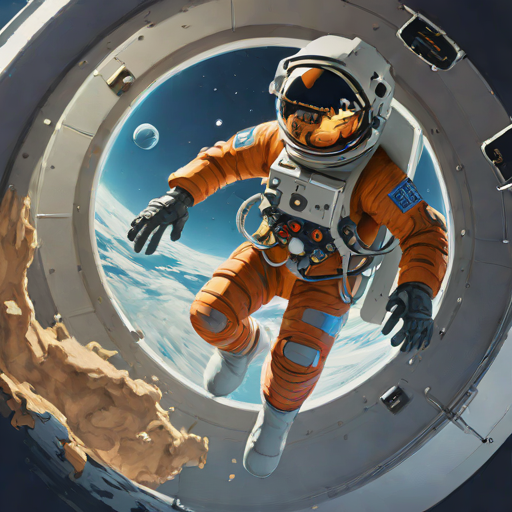

In [ ]:
image = pipeline_text2image(prompt=prompt, guidance_scale=0.0, num_inference_steps=4).images[0]
image

El parámetro `num_inference_steps` determina cuántos pasos realiza el proceso de difusión durante la generación.

En general, aumentar los pasos puede modificar el resultado y, en determinados modelos, mejorar la calidad; pero también aumenta el tiempo de cálculo. **SDXL Turbo está específicamente orientado a trabajar con muy pocos pasos**, por lo que resulta interesante comparar directamente distintos valores.

Prueba también a modificar el prompt. Por ejemplo, cambia el sujeto, el entorno o el estilo visual. El texto `8k` dentro de un prompt **no obliga al modelo a generar una imagen 8K**. Es simplemente una indicación textual y la resolución real depende de la configuración de generación.


  0%|          | 0/10 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


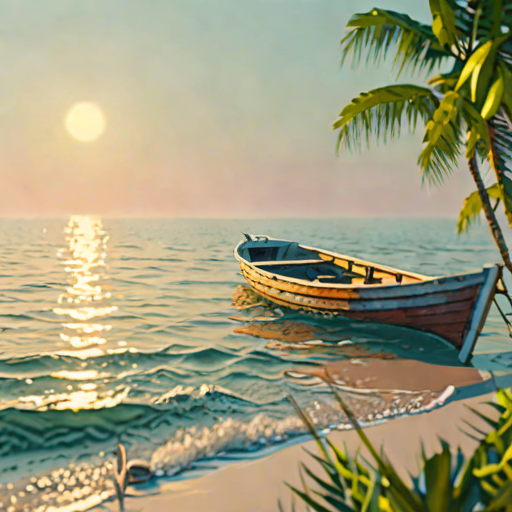

In [ ]:
prompt = "a boat in the water near the beach, realistic, detailed, 8k"

image = pipeline_text2image(prompt=prompt, guidance_scale=0.0, num_inference_steps=10)
image.images[0]

# Image-to-Image: transformar una imagen existente

Además de generar una imagen desde cero, podemos proporcionar una **imagen inicial** y utilizar un prompt para guiar su transformación.

Conceptualmente:

**imagen inicial + prompt → nueva imagen**

Esto permite conservar parte de la estructura de una imagen mientras modificamos su contenido o estilo.

In [ ]:
from diffusers import AutoPipelineForImage2Image
from diffusers.utils import load_image

pipeline_image2image = AutoPipelineForImage2Image.from_pipe(pipeline_text2image).to("cuda")

Usamos una imagen de ejemplo alojada en Hugging Face.

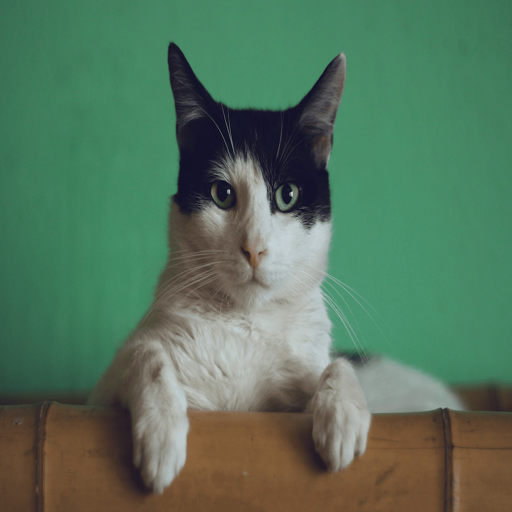

In [ ]:
init_image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png")
init_image = init_image.resize((512, 512))
init_image

El parámetro más importante que vamos a explorar aquí es **`strength`**.

- `strength` bajo → se conserva más información de la imagen inicial.
- `strength` alto → el modelo tiene más libertad para modificarla.

Por tanto, `strength` nos permite controlar el equilibrio entre **fidelidad a la imagen original** y **transformación guiada por el texto**.

In [ ]:
prompt = "cat wizard, gandalf, lord of the rings, detailed, fantasy, cute, adorable, Big Bang Theory style, 8k"

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


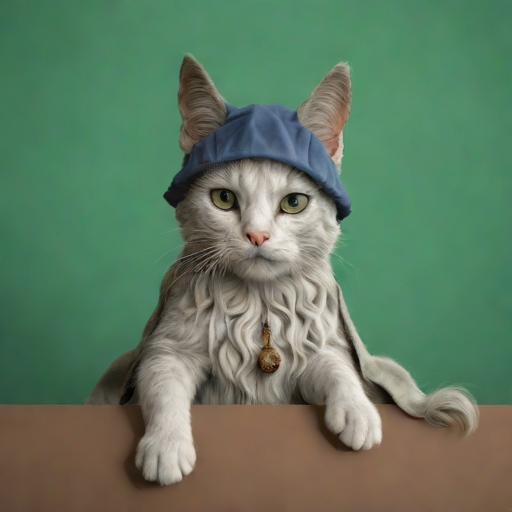

In [ ]:
image = pipeline_image2image(prompt, image=init_image, strength=0.5, guidance_scale=0.0, num_inference_steps=10).images[0]
image

Mantén la misma imagen y el mismo prompt y prueba, por ejemplo, `strength=0.2`, `0.5` y `0.8`.

Ahora partimos de una fotografía de una playa y utilizamos un prompt diferente para observar cómo el modelo puede reinterpretar la escena.

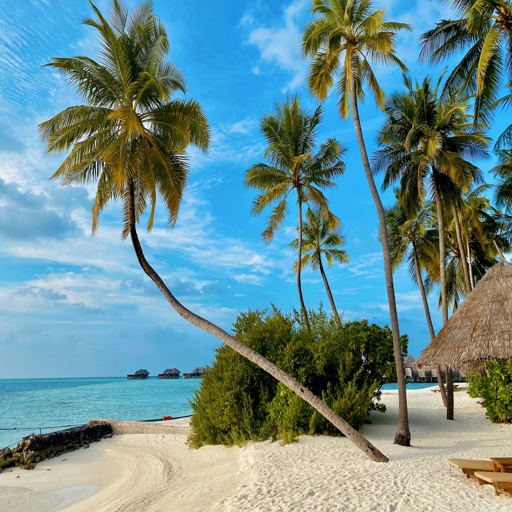

In [ ]:
init_image = load_image("https://images.unsplash.com/photo-1590523741831-ab7e8b8f9c7f?fm=jpg&q=60&w=3000&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8Mnx8cGxheWFzfGVufDB8fDB8fHww")
init_image = init_image.resize((512, 512))
init_image

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/5 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


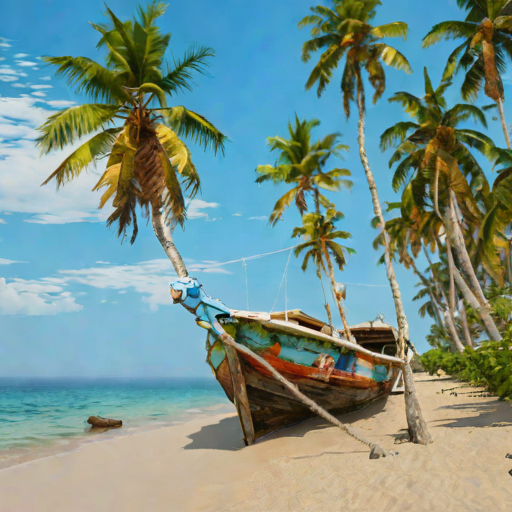

In [ ]:
prompt = "a boat in the water near the beach, realistic, detailed, 8k"

image = pipeline_image2image(prompt, image=init_image, strength=0.5, guidance_scale=0.0, num_inference_steps=10).images[0]
image